# Q1)

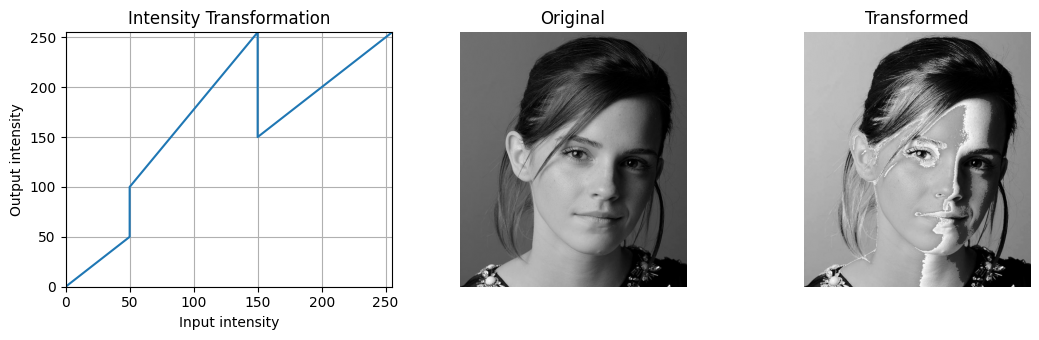

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    out = np.zeros_like(im, dtype=np.float32)
    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]
        if x1 == x2: continue
        m = (y2 - y1) / (x2 - x1)
        mask = (im >= x1) & (im <= x2)
        out[mask] = y1 + m * (im[mask] - x1)
    return np.clip(out, 0, 255).astype(np.uint8)

img = cv2.imread("/content/q1.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoints = np.array([[0, 0], [50, 50], [50, 100], [150, 255], [150, 150], [255, 255]], dtype=float)
transformed = intensity_transform(img, breakpoints)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1])
plt.xlim(0, 255); plt.ylim(0, 255)
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.title("Intensity Transformation")
plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed"); plt.axis("off")

plt.tight_layout()
plt.show()

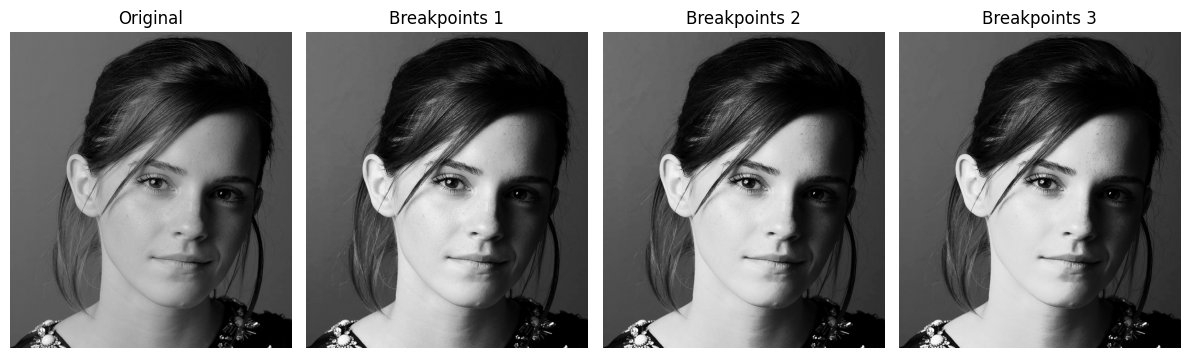

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    out = np.zeros_like(im, dtype=np.float32)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        m = (y2 - y1) / (x2 - x1)
        mask = (im >= x1) & (im <= x2)
        out[mask] = y1 + m * (im[mask] - x1)

    return np.clip(out, 0, 255).astype(np.uint8)


img = cv2.imread("/content/q1.jpeg", cv2.IMREAD_GRAYSCALE)

bp1 = np.array([[0,0], [40,25], [90,70], [140,165], [200,235], [255,255]], dtype=float)
bp2 = np.array([[0,0], [50,30], [100,85], [150,190], [210,240], [255,255]], dtype=float)
bp3 = np.array([[0,0], [60,35], [110,100], [160,205], [220,245], [255,255]], dtype=float)

out1 = intensity_transform(img, bp1)
out2 = intensity_transform(img, bp2)
out3 = intensity_transform(img, bp3)

plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1); plt.imshow(img, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(1, 4, 2); plt.imshow(out1, cmap="gray", vmin=0, vmax=255); plt.title("Breakpoints 1"); plt.axis("off")
plt.subplot(1, 4, 3); plt.imshow(out2, cmap="gray", vmin=0, vmax=255); plt.title("Breakpoints 2"); plt.axis("off")
plt.subplot(1, 4, 4); plt.imshow(out3, cmap="gray", vmin=0, vmax=255); plt.title("Breakpoints 3"); plt.axis("off")

plt.tight_layout()
plt.show()

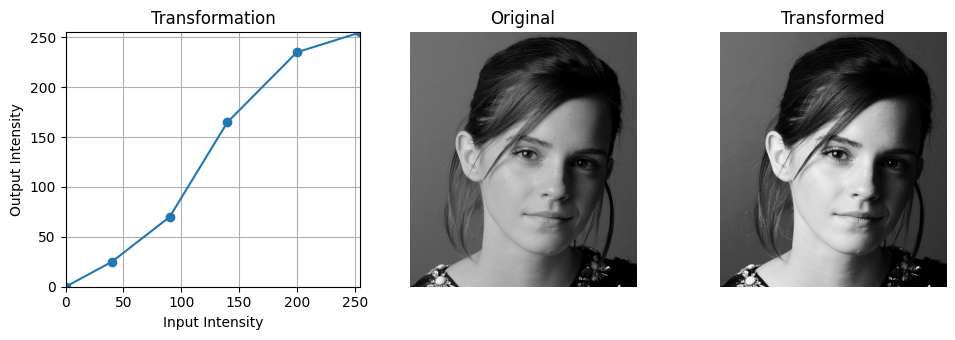

In [14]:
breakpoints = bp1
transformed = intensity_transform(img, breakpoints)

plt.figure(figsize=(10, 3.5))

plt.subplot(1, 3, 1)
plt.plot(breakpoints[:,0], breakpoints[:,1], marker="o")
plt.xlim(0,255); plt.ylim(0,255)
plt.xlabel("Input Intensity"); plt.ylabel("Output Intensity")
plt.title("Transformation"); plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed"); plt.axis("off")

plt.tight_layout()
plt.show()

# Q2)

/tmp/ipykernel_1776/411949390.py:37: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256], alpha=0.5, label="Original")
/tmp/ipykernel_1776/411949390.py:38: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(white.ravel(), 256, [0,256], alpha=0.5, label="White accentuated")
/tmp/ipykernel_1776/411949390.py:49: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0,256], alpha=0.5, label="Original")
/tmp/ipykernel_1776/411949390.py:50: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become ke

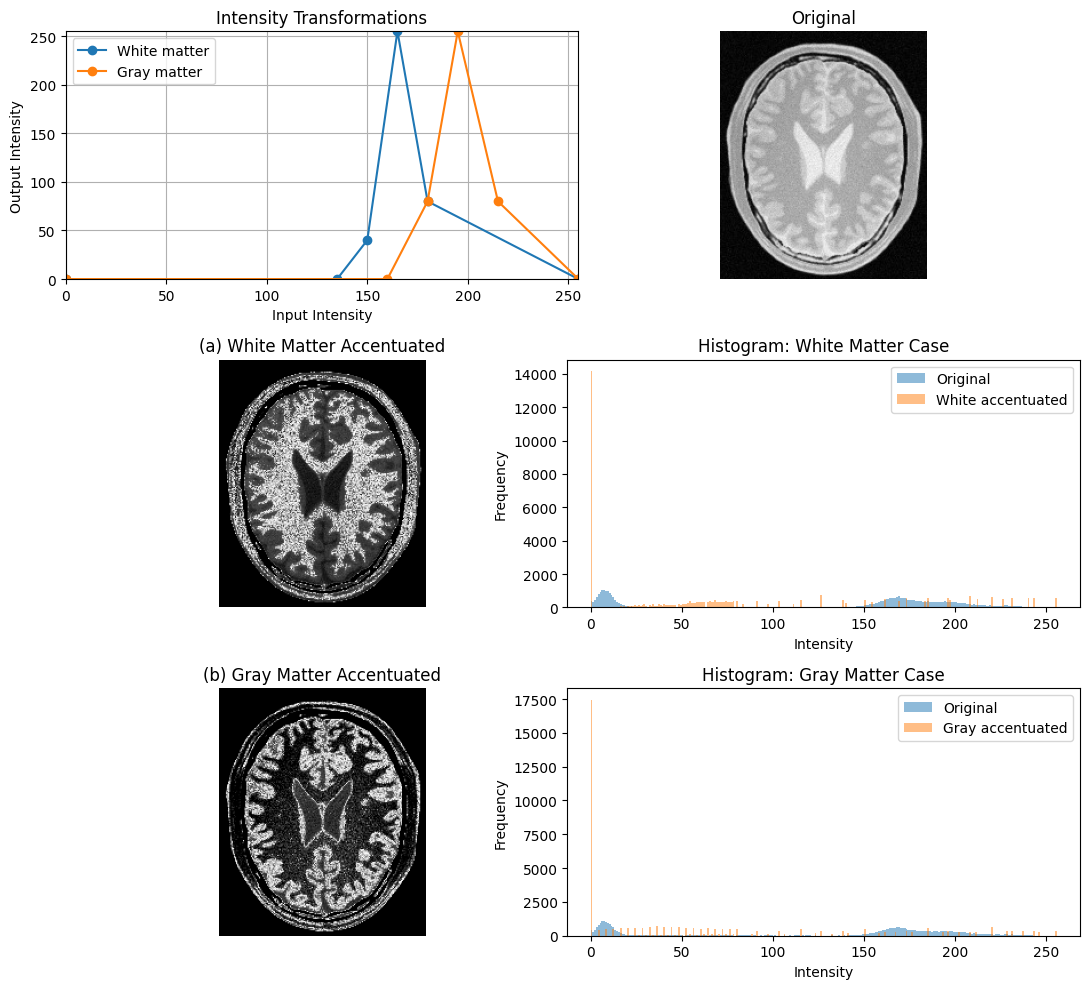

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    return np.interp(im, breakpoints[:, 0], breakpoints[:, 1]).astype(np.uint8)

img = cv2.imread("/content/q2.jpeg", cv2.IMREAD_GRAYSCALE)

bp_white = np.array([[0,0], [135,0], [150,40], [165,255], [180,80], [255,0]], dtype=float)
bp_gray = np.array([[0,0], [160,0], [180,80], [195,255], [215,80], [255,0]], dtype=float)

white = intensity_transform(img, bp_white)
gray = intensity_transform(img, bp_gray)

plt.figure(figsize=(11, 10))

plt.subplot(3, 2, 1)
plt.plot(bp_white[:,0], bp_white[:,1], marker="o", label="White matter")
plt.plot(bp_gray[:,0], bp_gray[:,1], marker="o", label="Gray matter")
plt.xlim(0,255); plt.ylim(0,255)
plt.xlabel("Input Intensity"); plt.ylabel("Output Intensity")
plt.title("Intensity Transformations")
plt.grid(); plt.legend()

plt.subplot(3, 2, 2)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(white, cmap="gray", vmin=0, vmax=255)
plt.title("(a) White Matter Accentuated")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.hist(img.ravel(), 256, [0,256], alpha=0.5, label="Original")
plt.hist(white.ravel(), 256, [0,256], alpha=0.5, label="White accentuated")
plt.title("Histogram: White Matter Case")
plt.xlabel("Intensity"); plt.ylabel("Frequency")
plt.legend()

plt.subplot(3, 2, 5)
plt.imshow(gray, cmap="gray", vmin=0, vmax=255)
plt.title("(b) Gray Matter Accentuated")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.hist(img.ravel(), 256, [0,256], alpha=0.5, label="Original")
plt.hist(gray.ravel(), 256, [0,256], alpha=0.5, label="Gray accentuated")
plt.title("Histogram: Gray Matter Case")
plt.xlabel("Intensity"); plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

The histograms of the transformed images confirm that the piecewise intensity transformations emphasize different intensity ranges. The white-matter transformation enhances a lower intensity band, while the gray-matter transformation enhances a slightly higher band, making the corresponding tissues more prominent.

# Q3)

/tmp/ipykernel_1776/3147421955.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(L.ravel(), 256, [0, 256], alpha=0.6, label="Original")
/tmp/ipykernel_1776/3147421955.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(L_corrected.ravel(), 256, [0, 256], alpha=0.6, label="Corrected")


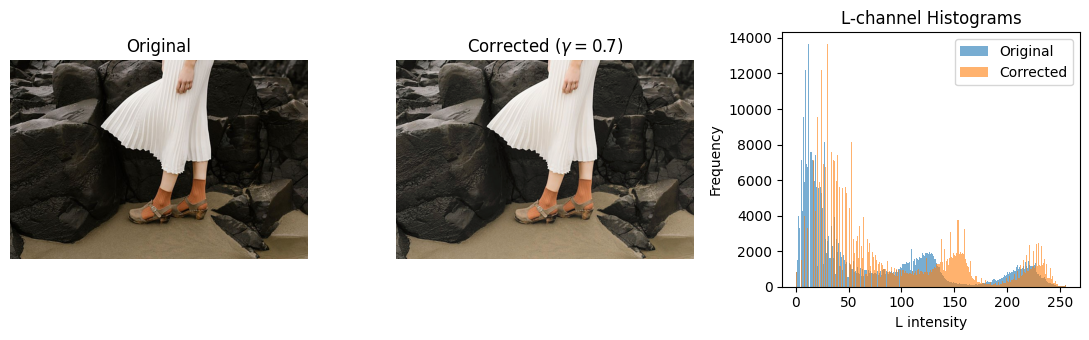

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/q3.jpeg")
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

gamma = 0.7
L_corrected = (255 * (L / 255.0) ** gamma).astype(np.uint8)

corrected_lab = cv2.merge([L_corrected, a, b])
corrected = cv2.cvtColor(corrected_lab, cv2.COLOR_LAB2RGB)
original = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1); plt.imshow(original); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(corrected); plt.title(r"Corrected ($\gamma=0.7$)"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.hist(L.ravel(), 256, [0, 256], alpha=0.6, label="Original")
plt.hist(L_corrected.ravel(), 256, [0, 256], alpha=0.6, label="Corrected")
plt.xlabel("L intensity"); plt.ylabel("Frequency")
plt.title("L-channel Histograms")
plt.legend()

plt.tight_layout()
plt.show()

# Q4 )

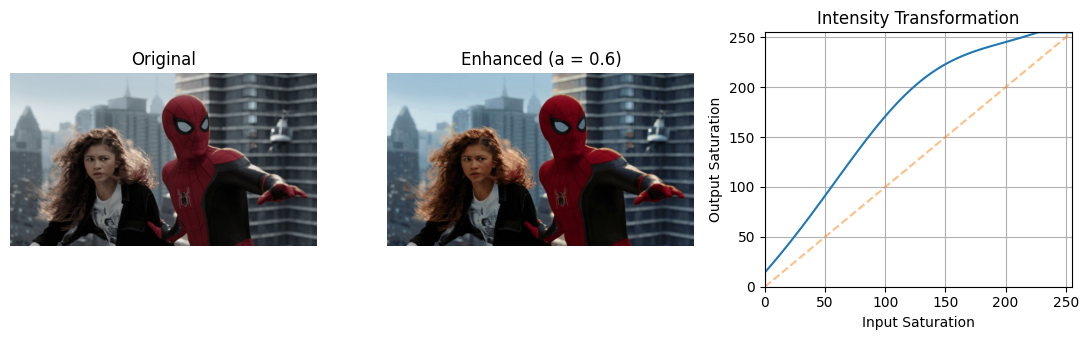

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("/content/q4.jpeg")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

a = 0.6
sigma = 70

S_new = S.astype(np.float32) + a * 128 * np.exp(-((S.astype(np.float32) - 128)**2) / (2 * sigma**2))
S_new = np.clip(S_new, 0, 255).astype(np.uint8)

enhanced_hsv = cv2.merge([H, S_new, V])
enhanced = cv2.cvtColor(enhanced_hsv, cv2.COLOR_HSV2RGB)

x = np.arange(256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255)

plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(enhanced); plt.title(f"Enhanced (a = {a})"); plt.axis("off")

plt.subplot(1, 3, 3)
plt.plot(x, f)
plt.plot(x, x, "--", alpha=0.5)
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title("Intensity Transformation")
plt.xlim(0, 255); plt.ylim(0, 255)
plt.grid()

plt.tight_layout()
plt.show()

# Q5)

/tmp/ipykernel_1776/240648316.py:21: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 3); plt.hist(img.ravel(), 256, [0,256]); plt.title("Histogram Before"); plt.xlabel("Intensity"); plt.ylabel("Frequency")
/tmp/ipykernel_1776/240648316.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 4); plt.hist(equalized.ravel(), 256, [0,256]); plt.title("Histogram After"); plt.xlabel("Intensity"); plt.ylabel("Frequency")


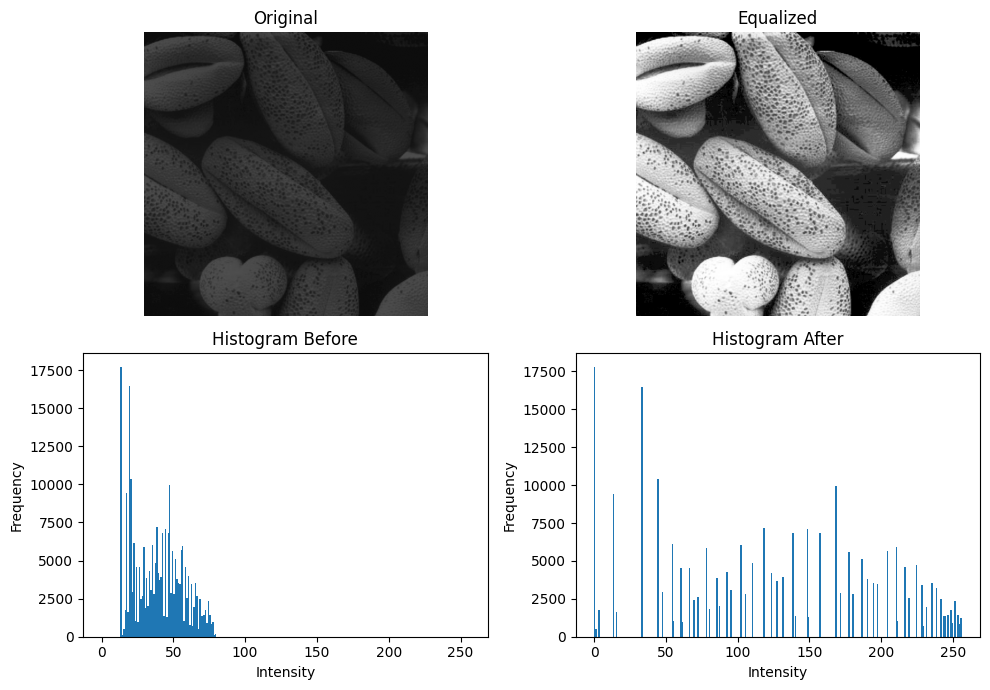

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def hist_equalize(im):
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = hist.cumsum()
    cdf_min = cdf[cdf > 0][0]
    lut = np.round((cdf - cdf_min) * 255 / (im.size - cdf_min))
    lut = np.clip(lut, 0, 255).astype(np.uint8)
    return lut[im]

img = cv2.imread("/content/shells.tif", cv2.IMREAD_GRAYSCALE)
equalized = hist_equalize(img)

plt.figure(figsize=(10, 7))

plt.subplot(2, 2, 1); plt.imshow(img, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(2, 2, 2); plt.imshow(equalized, cmap="gray", vmin=0, vmax=255); plt.title("Equalized"); plt.axis("off")

plt.subplot(2, 2, 3); plt.hist(img.ravel(), 256, [0,256]); plt.title("Histogram Before"); plt.xlabel("Intensity"); plt.ylabel("Frequency")
plt.subplot(2, 2, 4); plt.hist(equalized.ravel(), 256, [0,256]); plt.title("Histogram After"); plt.xlabel("Intensity"); plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Question 6)

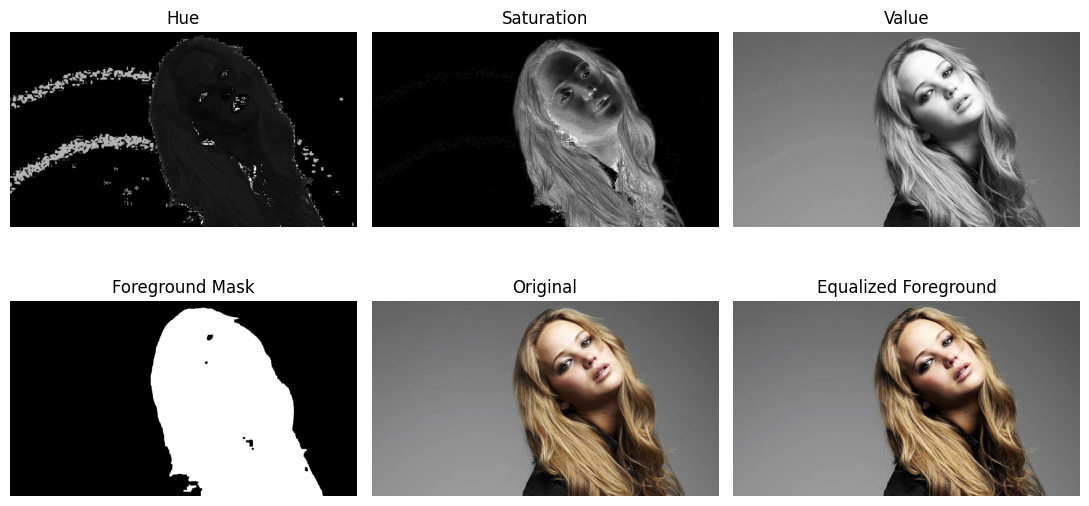

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("/content/WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg")
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

# Foreground mask using saturation
_, mask = cv2.threshold(S, 20, 255, cv2.THRESH_BINARY)

# Remove small isolated regions
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

# Foreground value plane
foreground = cv2.bitwise_and(V, V, mask=mask)

# Histogram of foreground only
hist = cv2.calcHist([V], [0], mask, [256], [0, 256]).ravel()

# Cumulative histogram
cdf = np.cumsum(hist)
cdf_min = cdf[cdf > 0][0]
N = np.count_nonzero(mask)

# Histogram equalization mapping
lut = np.round((cdf - cdf_min) * 255 / (N - cdf_min))
lut = np.clip(lut, 0, 255).astype(np.uint8)

# Equalize only foreground
V_eq = lut[V]
foreground_eq = cv2.bitwise_and(V_eq, V_eq, mask=mask)

# Original background
background = cv2.bitwise_and(V, V, mask=cv2.bitwise_not(mask))

# Combine equalized foreground and unchanged background
V_result = cv2.add(foreground_eq, background)

result_hsv = cv2.merge([H, S, V_result])
result = cv2.cvtColor(result_hsv, cv2.COLOR_HSV2RGB)

# Required outputs
plt.figure(figsize=(11, 6))

plt.subplot(2, 3, 1); plt.imshow(H, cmap="gray"); plt.title("Hue"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(S, cmap="gray"); plt.title("Saturation"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(V, cmap="gray"); plt.title("Value"); plt.axis("off")
plt.subplot(2, 3, 4); plt.imshow(mask, cmap="gray"); plt.title("Foreground Mask"); plt.axis("off")
plt.subplot(2, 3, 5); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(2, 3, 6); plt.imshow(result); plt.title("Equalized Foreground"); plt.axis("off")

plt.tight_layout()
plt.show()

# Question 7)

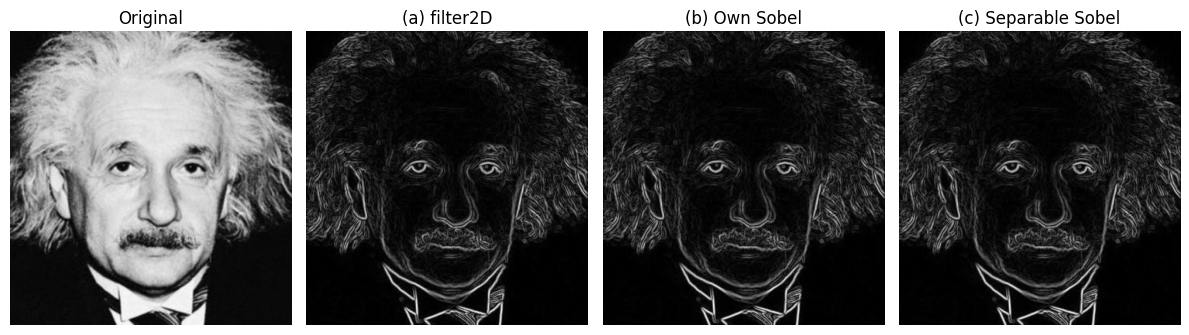

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/q7.jpeg", cv2.IMREAD_GRAYSCALE)

Kx = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
Ky = Kx.T

# (a) Sobel using filter2D
gx1 = cv2.filter2D(img, cv2.CV_32F, Kx, borderType=cv2.BORDER_REFLECT_101)
gy1 = cv2.filter2D(img, cv2.CV_32F, Ky, borderType=cv2.BORDER_REFLECT_101)
mag1 = cv2.magnitude(gx1, gy1)

# (b) Own filtering function
def my_filter2d(im, kernel):
    r = kernel.shape[0] // 2
    padded = np.pad(im.astype(np.float32), r, mode="reflect")
    out = np.zeros(im.shape, dtype=np.float32)
    for y in range(im.shape[0]):
        for x in range(im.shape[1]):
            out[y,x] = np.sum(padded[y:y+2*r+1, x:x+2*r+1] * kernel)
    return out

gx2 = my_filter2d(img, Kx)
gy2 = my_filter2d(img, Ky)
mag2 = np.sqrt(gx2**2 + gy2**2)

# (c) Sobel using separability
smooth = np.array([1,2,1], dtype=np.float32)
deriv = np.array([1,0,-1], dtype=np.float32)

gx3 = cv2.sepFilter2D(img, cv2.CV_32F, deriv, smooth, borderType=cv2.BORDER_REFLECT_101)
gy3 = cv2.sepFilter2D(img, cv2.CV_32F, smooth, deriv, borderType=cv2.BORDER_REFLECT_101)
mag3 = cv2.magnitude(gx3, gy3)

# Normalize only for display
m1 = cv2.normalize(mag1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
m2 = cv2.normalize(mag2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
m3 = cv2.normalize(mag3, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(12, 4))
plt.subplot(1,4,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(m1, cmap="gray"); plt.title("(a) filter2D"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(m2, cmap="gray"); plt.title("(b) Own Sobel"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(m3, cmap="gray"); plt.title("(c) Separable Sobel"); plt.axis("off")
plt.tight_layout()
plt.show()

# Question 8)

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def zoom_image(im, s, method):
    h, w = im.shape[:2]
    H, W = int(round(h * s)), int(round(w * s))

    y = (np.arange(H) + 0.5) / s - 0.5
    x = (np.arange(W) + 0.5) / s - 0.5

    if method == "nearest":
        yi = np.clip(np.rint(y).astype(int), 0, h - 1)
        xi = np.clip(np.rint(x).astype(int), 0, w - 1)
        return im[yi[:, None], xi[None, :]]

    y0 = np.floor(y).astype(int)
    x0 = np.floor(x).astype(int)
    wy, wx = y - y0, x - x0

    y0 = np.clip(y0, 0, h - 1)
    x0 = np.clip(x0, 0, w - 1)
    y1 = np.clip(y0 + 1, 0, h - 1)
    x1 = np.clip(x0 + 1, 0, w - 1)

    Ia = im[y0[:,None], x0[None,:]].astype(float)
    Ib = im[y0[:,None], x1[None,:]].astype(float)
    Ic = im[y1[:,None], x0[None,:]].astype(float)
    Id = im[y1[:,None], x1[None,:]].astype(float)

    wy = wy[:,None,None]
    wx = wx[None,:,None]

    out = (1-wy)*(1-wx)*Ia + (1-wy)*wx*Ib + wy*(1-wx)*Ic + wy*wx*Id
    return np.clip(out, 0, 255).astype(np.uint8)

def nssd(a, b):
    return np.mean(((a.astype(float) - b.astype(float)) / 255.0) ** 2)

In [33]:
orig1 = cv2.cvtColor(cv2.imread("/content/im01.png"), cv2.COLOR_BGR2RGB)
small1 = cv2.cvtColor(cv2.imread("/content/im01small.png"), cv2.COLOR_BGR2RGB)

orig2 = cv2.cvtColor(cv2.imread("/content/im02.png"), cv2.COLOR_BGR2RGB)
small2 = cv2.cvtColor(cv2.imread("/content/im02small.png"), cv2.COLOR_BGR2RGB)

nn1 = zoom_image(small1, 4, "nearest")
bl1 = zoom_image(small1, 4, "bilinear")

nn2 = zoom_image(small2, 4, "nearest")
bl2 = zoom_image(small2, 4, "bilinear")

print("Image 1")
print("Nearest-neighbor NSSD:", nssd(orig1, nn1))
print("Bilinear NSSD       :", nssd(orig1, bl1))

print("\nImage 2")
print("Nearest-neighbor NSSD:", nssd(orig2, nn2))
print("Bilinear NSSD       :", nssd(orig2, bl2))

Image 1
Nearest-neighbor NSSD: 0.0020956408919171657
Bilinear NSSD       : 0.001776520977904191

Image 2
Nearest-neighbor NSSD: 0.0004067064572742678
Bilinear NSSD       : 0.0002829426426979651


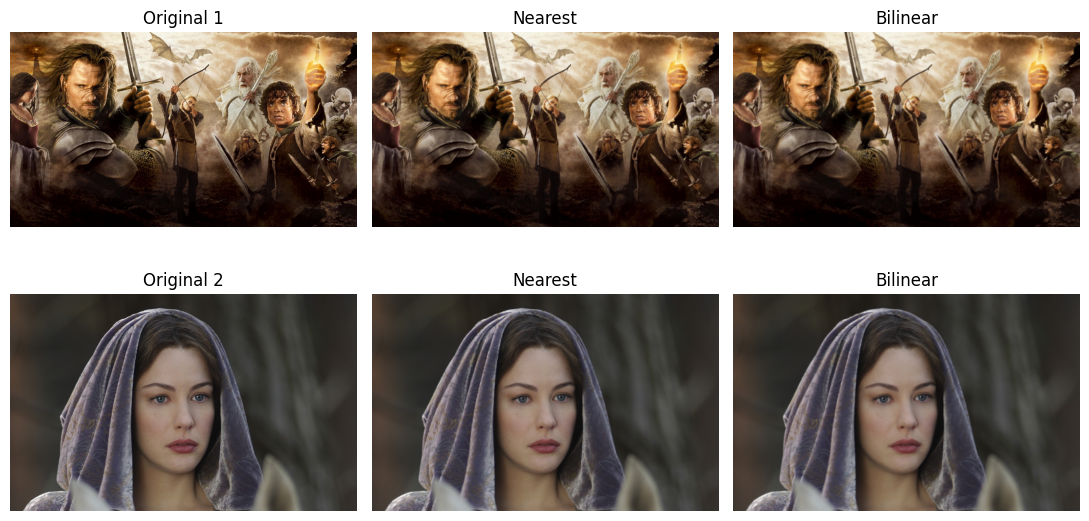

In [34]:
plt.figure(figsize=(11, 6))

plt.subplot(2,3,1); plt.imshow(orig1); plt.title("Original 1"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(nn1); plt.title("Nearest"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(bl1); plt.title("Bilinear"); plt.axis("off")

plt.subplot(2,3,4); plt.imshow(orig2); plt.title("Original 2"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(nn2); plt.title("Nearest"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(bl2); plt.title("Bilinear"); plt.axis("off")

plt.tight_layout()
plt.show()

Nearest-neighbor and bilinear interpolation were implemented for image scaling using inverse coordinate mapping. The supplied low-resolution images were enlarged by a factor of four and compared with their corresponding original images using normalized SSD. Bilinear interpolation generally produced lower error and smoother results than nearest-neighbor interpolation.

# Q9)
a )

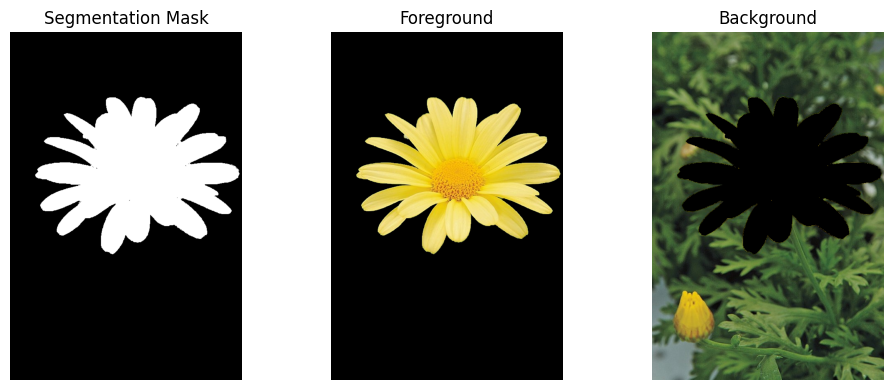

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread("/content/flower.jpeg"), cv2.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], np.uint8)
bgd = np.zeros((1, 65), np.float64)
fgd = np.zeros((1, 65), np.float64)

rect = (20, 120, 535, 450)
cv2.grabCut(img, mask, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)

mask = np.where((mask == 1) | (mask == 3), 1, 0).astype("uint8")
m = mask[:, :, None]

foreground = img * m
background = img * (1 - m)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(mask, cmap="gray"); plt.title("Segmentation Mask"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(foreground); plt.title("Foreground"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(background); plt.title("Background"); plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
rect = (20, 120, 535, 450)

b)

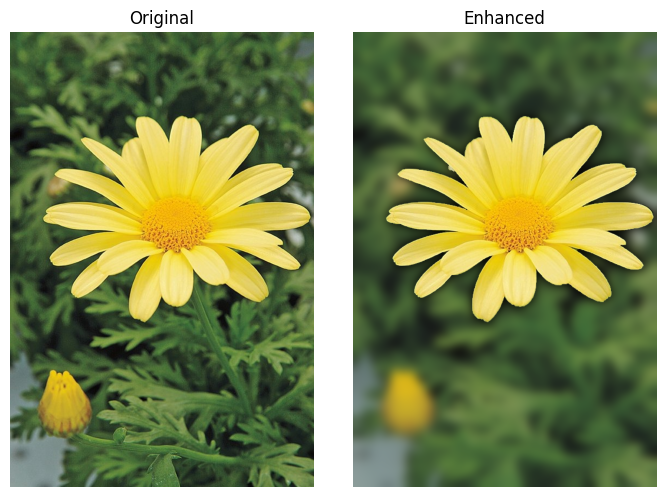

In [4]:
blurred_background = cv2.GaussianBlur(background, (61, 61), 0)
blurred_background = blurred_background * (1 - m)
enhanced = foreground + blurred_background

plt.figure(figsize=(7, 5))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(enhanced); plt.title("Enhanced"); plt.axis("off")
plt.tight_layout()
plt.show()

The foreground pixels are set to zero in the extracted background image. When this background is Gaussian blurred, pixels just outside the flower boundary are averaged with these zero-valued pixels, reducing their intensity. This produces the dark region around the edge of the flower.

# Question 10)
a)

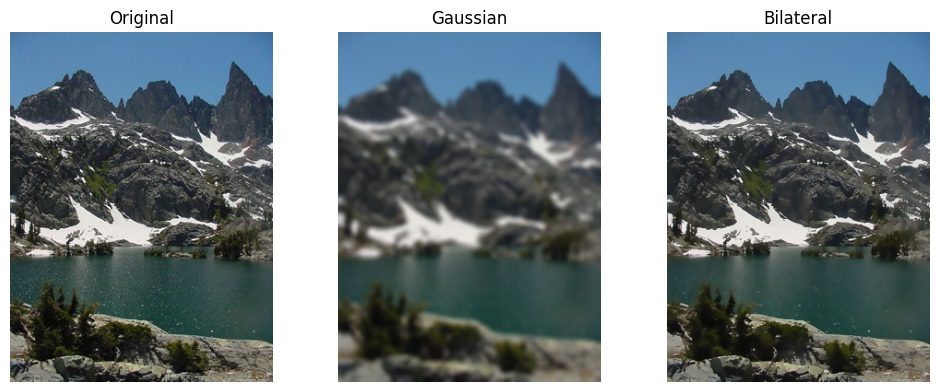

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread("/content/lake.jpeg"), cv2.COLOR_BGR2RGB)

gaussian = cv2.GaussianBlur(img, (9, 9), 3)
bilateral = cv2.bilateralFilter(img, 9, 50, 3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(gaussian); plt.title("Gaussian"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(bilateral); plt.title("Bilateral"); plt.axis("off")
plt.tight_layout()
plt.show()

A Gaussian filter smooths the image but also blurs significant edges. The bilateral filter combines spatial proximity and intensity/color similarity when computing the weighted average. Consequently, pixels across strong edges receive small weights, allowing noise and fine variations to be smoothed while retaining prominent boundaries.

b) Bilateral Filter

In [7]:
def my_bilateral(img, d=9, sigma_r=50, sigma_s=3):
    r = d // 2
    x = img.astype(np.float32)
    pad = cv2.copyMakeBorder(x, r, r, r, r, cv2.BORDER_REFLECT_101)

    num = np.zeros_like(x)
    den = np.zeros(x.shape[:2], np.float32)

    for dy in range(-r, r + 1):
        for dx in range(-r, r + 1):
            shifted = pad[r+dy:r+dy+x.shape[0], r+dx:r+dx+x.shape[1]]
            ws = np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
            wr = np.exp(-np.sum((x - shifted)**2, axis=2) / (2 * sigma_r**2))
            w = ws * wr
            num += shifted * w[:, :, None]
            den += w

    return np.clip(num / den[:, :, None], 0, 255).astype(np.uint8)

custom = my_bilateral(img, 9, 50, 3)

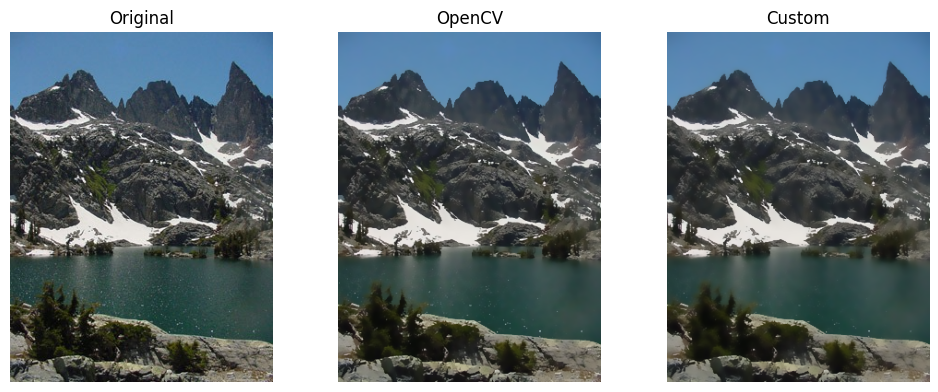

In [8]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(bilateral); plt.title("OpenCV"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(custom); plt.title("Custom"); plt.axis("off")
plt.tight_layout()
plt.show()

In [9]:
mse = np.mean((bilateral.astype(float) - custom.astype(float))**2)
psnr = 10 * np.log10(255**2 / mse)

print("MSE :", mse)
print("PSNR:", psnr, "dB")

MSE : 15.603659587565405
PSNR: 36.198538937766415 dB


A bilateral filter was implemented using spatial and range Gaussian weights. The custom implementation produced a visually similar result to OpenCV's bilateralFilter. The similarity was quantified using MSE and PSNR, where a low MSE and high PSNR indicate close agreement between the two implementations.